# E-commerce Checkout A/B Test
## Exploratory Segment Analysis

### Executive Summary

The primary analysis found an overall **+2.16 percentage-point** treatment lift in 24-hour purchase conversion. This notebook evaluates whether that effect is consistent across the three segment dimensions pre-specified in the experiment design:

- new versus returning users;
- device at first valid checkout exposure; and
- traffic source at first valid checkout exposure.

All ten subgroup point estimates are positive. Several subgroup-level tests are individually significant after false-discovery-rate adjustment, but the correct tests of **effect differences across subgroups** find no statistically confirmed heterogeneity:

- user type: Holm-adjusted `p = 1.0000`;
- device: Holm-adjusted `p = 1.0000`; and
- traffic source: raw `p = 0.0628`, Holm-adjusted `p = 0.1883`.

The overall result is not driven by one visibly anomalous segment, but the current evidence does not justify claiming that treatment works better for a particular user type, device, or traffic source. Segment findings remain exploratory.

### Analysis Framework

| Component | Definition |
|---|---|
| Population | The same 15,467 eligible mature checkout-exposed users used in the primary analysis |
| Analysis unit | One row per user |
| Outcome | At least one purchase after a qualifying payment attempt and within 24 hours of exposure |
| Segment dimensions | `user_type`, `device_at_exposure`, and `traffic_source_at_exposure` |
| Within-level estimate | Treatment conversion minus control conversion |
| Within-level uncertainty | Two-sided z-test and unpooled 95% confidence interval |
| Multiple subgroup tests | Benjamini–Hochberg adjustment across all 10 subgroup-level p-values |
| Heterogeneity test | Inverse-variance Q test of equal absolute risk differences within each dimension |
| Multiple heterogeneity tests | Holm adjustment across the three dimension-level tests |
| Status | Exploratory, as pre-specified |

A significant treatment effect inside one subgroup and a non-significant effect inside another subgroup do **not** establish that the two effects differ. Heterogeneity must be tested directly.

In [1]:
from pathlib import Path
from math import sqrt
from statistics import NormalDist
import os
import sqlite3
import tempfile

os.environ.setdefault(
    "MPLCONFIGDIR",
    str(Path(tempfile.gettempdir()) / "matplotlib-cache"),
)

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import pandas as pd
from scipy.stats import chi2

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 180)

START_DIR = Path.cwd().resolve()
PROJECT_ROOT = None

for path in [START_DIR, *START_DIR.parents]:
    if (
        path.name == "week2_checkout_experiment"
        and (path / "data" / "raw").is_dir()
    ):
        PROJECT_ROOT = path
        break

    candidate = path / "week2_checkout_experiment"
    if (candidate / "data" / "raw").is_dir():
        PROJECT_ROOT = candidate
        break

if PROJECT_ROOT is None:
    raise FileNotFoundError(
        "Could not locate the week2_checkout_experiment directory."
    )

RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"
FUNNEL_SQL_PATH = PROJECT_ROOT / "sql" / "02_funnel_analysis.sql"

print("Project root:", PROJECT_ROOT.name)
print("Reused SQL definition:", FUNNEL_SQL_PATH.relative_to(PROJECT_ROOT))

Project root: week2_checkout_experiment
Reused SQL definition: sql/02_funnel_analysis.sql


## 1. Rebuild the Canonical User-Level Funnel

The notebook executes the unchanged canonical funnel SQL against the versioned raw CSV files. No segment-specific filtering or outcome definition is introduced.

In [2]:
conn = sqlite3.connect(":memory:")

for table_name in ["users", "experiment_assignments", "events", "orders"]:
    table = pd.read_csv(RAW_DATA_DIR / f"{table_name}.csv")
    table.to_sql(table_name, conn, index=False, if_exists="replace")

conn.executescript(FUNNEL_SQL_PATH.read_text(encoding="utf-8"))

analysis_data = pd.read_sql_query(
    """
    SELECT
        user_id,
        experiment_group,
        reached_purchase,
        user_type,
        device_at_exposure,
        traffic_source_at_exposure
    FROM user_level_funnel
    ORDER BY user_id;
    """,
    conn,
)

segment_columns = [
    "user_type",
    "device_at_exposure",
    "traffic_source_at_exposure",
]

assert len(analysis_data) == 15_467
assert analysis_data["user_id"].nunique() == len(analysis_data)
assert not analysis_data[segment_columns].isna().any().any()
assert set(analysis_data["reached_purchase"]) <= {0, 1}

print("Analysis rows:", f"{len(analysis_data):,}")
print("Unique users:", f"{analysis_data['user_id'].nunique():,}")
print("Missing segment values:", int(analysis_data[segment_columns].isna().sum().sum()))

Analysis rows: 15,467
Unique users: 15,467
Missing segment values: 0


## 2. Estimate Treatment Effects Within Each Segment Level

Each segment level retains the same user-level binary outcome as the primary analysis. The pooled standard error is used for the within-level null-hypothesis test; the unpooled standard error is used for the confidence interval around the observed risk difference.

In [3]:
normal = NormalDist()
alpha = 0.05
z_critical = normal.inv_cdf(1 - alpha / 2)

segment_definitions = [
    ("user_type", "User type", ["new", "returning"]),
    ("device_at_exposure", "Device", ["desktop", "mobile", "tablet"]),
    (
        "traffic_source_at_exposure",
        "Traffic source",
        ["direct", "email", "organic", "paid_search", "social"],
    ),
]

def estimate_binary_effect(data):
    group_counts = (
        data.groupby("experiment_group")["reached_purchase"]
        .agg(["count", "sum"])
    )

    if set(group_counts.index) != {"control", "treatment"}:
        raise ValueError("Each segment level must contain both experiment groups.")

    n_control = int(group_counts.loc["control", "count"])
    x_control = int(group_counts.loc["control", "sum"])
    n_treatment = int(group_counts.loc["treatment", "count"])
    x_treatment = int(group_counts.loc["treatment", "sum"])

    p_control = x_control / n_control
    p_treatment = x_treatment / n_treatment
    absolute_lift = p_treatment - p_control
    relative_lift = absolute_lift / p_control

    pooled_rate = (x_control + x_treatment) / (n_control + n_treatment)
    pooled_se = sqrt(
        pooled_rate
        * (1 - pooled_rate)
        * (1 / n_control + 1 / n_treatment)
    )
    unpooled_se = sqrt(
        p_control * (1 - p_control) / n_control
        + p_treatment * (1 - p_treatment) / n_treatment
    )

    z_statistic = absolute_lift / pooled_se
    p_value = 2 * normal.cdf(-abs(z_statistic))

    return {
        "control_users": n_control,
        "treatment_users": n_treatment,
        "control_purchases": x_control,
        "treatment_purchases": x_treatment,
        "control_rate": p_control,
        "treatment_rate": p_treatment,
        "absolute_lift": absolute_lift,
        "relative_lift": relative_lift,
        "unpooled_se": unpooled_se,
        "ci_lower": absolute_lift - z_critical * unpooled_se,
        "ci_upper": absolute_lift + z_critical * unpooled_se,
        "z_statistic": z_statistic,
        "p_value": p_value,
    }

def benjamini_hochberg(p_values):
    p_values = pd.Series(p_values, dtype=float)
    ordered_index = p_values.sort_values(kind="mergesort").index
    adjusted = pd.Series(index=p_values.index, dtype=float)
    running_minimum = 1.0
    m = len(p_values)

    for rank, index in reversed(list(enumerate(ordered_index, start=1))):
        candidate = min(1.0, p_values.loc[index] * m / rank)
        running_minimum = min(running_minimum, candidate)
        adjusted.loc[index] = running_minimum

    return adjusted

segment_rows = []
for dimension, dimension_label, ordered_levels in segment_definitions:
    for level in ordered_levels:
        level_data = analysis_data.loc[analysis_data[dimension].eq(level)]
        effect = estimate_binary_effect(level_data)
        segment_rows.append(
            {
                "segment_dimension": dimension,
                "dimension_label": dimension_label,
                "segment_level": level,
                **effect,
            }
        )

segment_results = pd.DataFrame(segment_rows)
segment_results["bh_adjusted_p"] = benjamini_hochberg(
    segment_results["p_value"]
)
segment_results["fdr_significant_05"] = segment_results[
    "bh_adjusted_p"
] < alpha

overall_effect = estimate_binary_effect(analysis_data)

assert len(segment_results) == 10
assert (segment_results["control_users"] > 0).all()
assert (segment_results["treatment_users"] > 0).all()

In [4]:
segment_display = segment_results[
    [
        "dimension_label",
        "segment_level",
        "control_users",
        "treatment_users",
        "control_rate",
        "treatment_rate",
        "absolute_lift",
        "relative_lift",
        "ci_lower",
        "ci_upper",
        "p_value",
        "bh_adjusted_p",
    ]
].copy()

segment_display["control_rate"] = segment_display["control_rate"].map(
    "{:.2%}".format
)
segment_display["treatment_rate"] = segment_display["treatment_rate"].map(
    "{:.2%}".format
)
segment_display["absolute_lift"] = segment_display["absolute_lift"].map(
    lambda value: f"{value * 100:+.2f} pp"
)
segment_display["relative_lift"] = segment_display["relative_lift"].map(
    lambda value: f"{value:+.2%}"
)
segment_display["95% CI"] = [
    f"[{lower * 100:+.2f}, {upper * 100:+.2f}] pp"
    for lower, upper in zip(
        segment_display.pop("ci_lower"),
        segment_display.pop("ci_upper"),
    )
]
segment_display["p_value"] = segment_display["p_value"].map("{:.4f}".format)
segment_display["bh_adjusted_p"] = segment_display[
    "bh_adjusted_p"
].map("{:.4f}".format)

segment_display = segment_display.rename(
    columns={
        "dimension_label": "dimension",
        "segment_level": "level",
        "control_users": "control_n",
        "treatment_users": "treatment_n",
        "absolute_lift": "lift",
        "relative_lift": "relative_lift",
        "bh_adjusted_p": "BH_q",
    }
)

for dimension_label in segment_display["dimension"].drop_duplicates():
    print(f"\n{dimension_label}")
    print(
        segment_display.loc[
            segment_display["dimension"].eq(dimension_label)
        ].drop(columns="dimension").to_string(index=False)
    )


User type
    level  control_n  treatment_n control_rate treatment_rate     lift relative_lift p_value   BH_q            95% CI
      new       2371         2292       26.23%         28.27% +2.04 pp        +7.77%  0.1180 0.2360 [-0.52, +4.59] pp
returning       5383         5421       28.01%         30.20% +2.18 pp        +7.79%  0.0125 0.0312 [+0.47, +3.90] pp

Device
  level  control_n  treatment_n control_rate treatment_rate     lift relative_lift p_value   BH_q            95% CI
desktop       2805         2785       27.99%         29.66% +1.67 pp        +5.98%  0.1673 0.2788 [-0.70, +4.05] pp
 mobile       4461         4469       27.03%         29.49% +2.46 pp        +9.09%  0.0099 0.0312 [+0.59, +4.32] pp
 tablet        488          459       28.48%         30.72% +2.24 pp        +7.85%  0.4512 0.5641 [-3.58, +8.05] pp

Traffic source
      level  control_n  treatment_n control_rate treatment_rate     lift relative_lift p_value   BH_q            95% CI
     direct       1282     

### Multiple-Testing Interpretation

The Benjamini–Hochberg adjustment controls the expected false discovery rate across the ten within-level tests. Returning users, mobile users, email traffic, and social traffic retain `q < 0.05`. These results show evidence of a positive treatment effect **within** those levels; they do not show that their effects are larger than the effects in other levels.

## 3. Test Treatment-Effect Heterogeneity Directly

For each segment dimension, an inverse-variance Q test evaluates whether the absolute treatment-control risk differences are consistent with one common effect. Holm adjustment controls the family-wise error rate across the three dimension-level heterogeneity tests.

In [5]:
def holm_adjust(p_values):
    p_values = pd.Series(p_values, dtype=float)
    ordered_index = p_values.sort_values(kind="mergesort").index
    adjusted = pd.Series(index=p_values.index, dtype=float)
    running_maximum = 0.0
    m = len(p_values)

    for rank, index in enumerate(ordered_index, start=1):
        candidate = min(1.0, (m - rank + 1) * p_values.loc[index])
        running_maximum = max(running_maximum, candidate)
        adjusted.loc[index] = running_maximum

    return adjusted

heterogeneity_rows = []
for dimension, dimension_label, _ in segment_definitions:
    dimension_results = segment_results.loc[
        segment_results["segment_dimension"].eq(dimension)
    ].copy()

    weights = 1 / dimension_results["unpooled_se"].pow(2)
    weighted_effect = (
        weights * dimension_results["absolute_lift"]
    ).sum() / weights.sum()
    q_statistic = (
        weights
        * (dimension_results["absolute_lift"] - weighted_effect).pow(2)
    ).sum()
    degrees_of_freedom = len(dimension_results) - 1
    p_value = chi2.sf(q_statistic, degrees_of_freedom)

    heterogeneity_rows.append(
        {
            "segment_dimension": dimension,
            "dimension": dimension_label,
            "levels": len(dimension_results),
            "weighted_effect": weighted_effect,
            "q_statistic": q_statistic,
            "degrees_of_freedom": degrees_of_freedom,
            "p_value": p_value,
        }
    )

heterogeneity_results = pd.DataFrame(heterogeneity_rows)
heterogeneity_results["holm_adjusted_p"] = holm_adjust(
    heterogeneity_results["p_value"]
)
heterogeneity_results["confirmed_heterogeneity_05"] = (
    heterogeneity_results["holm_adjusted_p"] < alpha
)

heterogeneity_display = heterogeneity_results.copy()
heterogeneity_display["weighted_effect"] = heterogeneity_display[
    "weighted_effect"
].map(lambda value: f"{value * 100:+.2f} pp")
heterogeneity_display["q_statistic"] = heterogeneity_display[
    "q_statistic"
].round(3)
heterogeneity_display["p_value"] = heterogeneity_display["p_value"].map(
    "{:.4f}".format
)
heterogeneity_display["holm_adjusted_p"] = heterogeneity_display[
    "holm_adjusted_p"
].map("{:.4f}".format)

print(
    heterogeneity_display[
        [
            "dimension",
            "levels",
            "weighted_effect",
            "q_statistic",
            "degrees_of_freedom",
            "p_value",
            "holm_adjusted_p",
            "confirmed_heterogeneity_05",
        ]
    ].to_string(index=False)
)

assert not heterogeneity_results["confirmed_heterogeneity_05"].any()

     dimension  levels weighted_effect  q_statistic  degrees_of_freedom p_value holm_adjusted_p  confirmed_heterogeneity_05
     User type       2        +2.14 pp        0.008                   1  0.9266          1.0000                       False
        Device       3        +2.16 pp        0.260                   2  0.8782          1.0000                       False
Traffic source       5        +2.14 pp        8.934                   4  0.0628          0.1883                       False


## 4. Visualize Segment Effects and Precision

The forest plot shows absolute conversion lift and 95% confidence intervals. The solid vertical line marks no treatment effect; the dashed line marks the overall estimate. Wide intervals signal low segment-level precision even when point estimates look large.

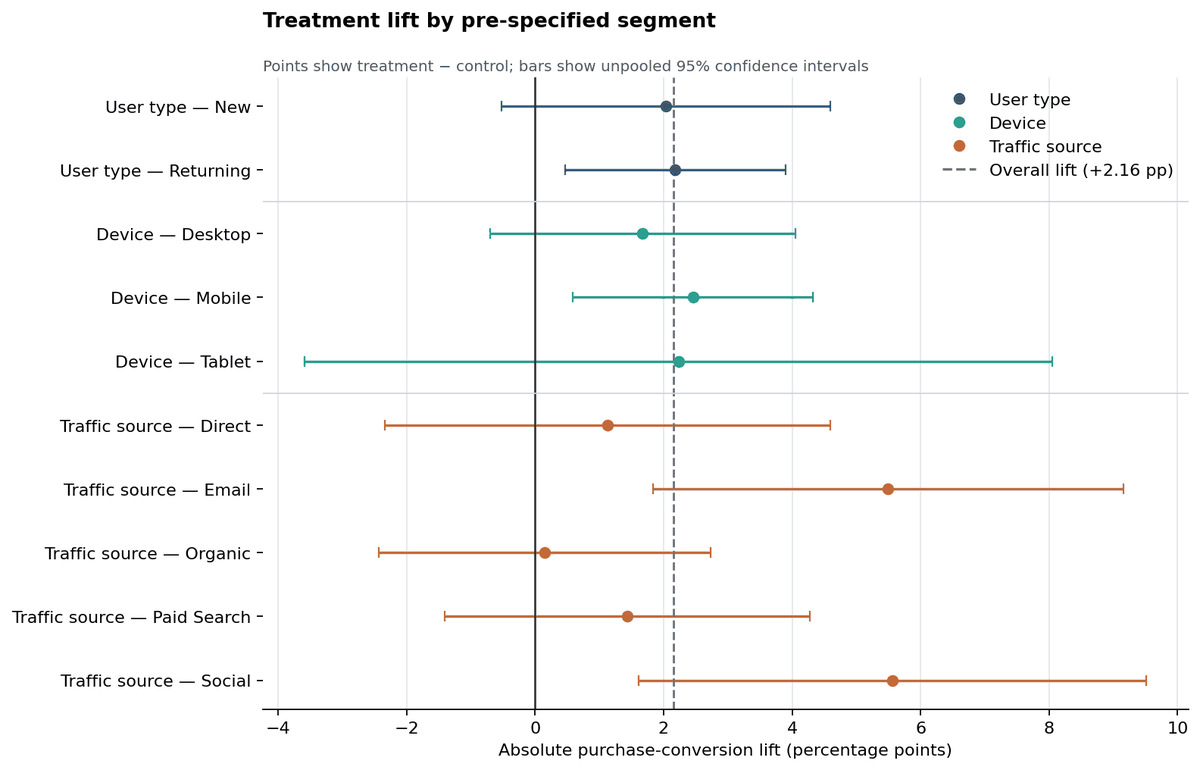

In [6]:
plot_data = segment_results.copy()
plot_data["plot_label"] = (
    plot_data["dimension_label"]
    + " — "
    + plot_data["segment_level"].str.replace("_", " ").str.title()
)
plot_data["effect_pp"] = plot_data["absolute_lift"] * 100
plot_data["lower_pp"] = plot_data["ci_lower"] * 100
plot_data["upper_pp"] = plot_data["ci_upper"] * 100

dimension_colors = {
    "User type": "#355C7D",
    "Device": "#2A9D8F",
    "Traffic source": "#C46A3A",
}

fig, ax = plt.subplots(figsize=(10, 6.5))
y_positions = list(range(len(plot_data) - 1, -1, -1))

for y_position, (_, row) in zip(y_positions, plot_data.iterrows()):
    ax.errorbar(
        row["effect_pp"],
        y_position,
        xerr=[[row["effect_pp"] - row["lower_pp"]], [row["upper_pp"] - row["effect_pp"]]],
        fmt="o",
        color=dimension_colors[row["dimension_label"]],
        ecolor=dimension_colors[row["dimension_label"]],
        capsize=3,
        markersize=6,
        linewidth=1.5,
    )

ax.axvline(0, color="#333333", linewidth=1.2)
ax.axvline(
    overall_effect["absolute_lift"] * 100,
    color="#6B7280",
    linestyle="--",
    linewidth=1.3,
)
ax.axhline(7.5, color="#D1D5DB", linewidth=0.8)
ax.axhline(4.5, color="#D1D5DB", linewidth=0.8)

ax.set_yticks(y_positions)
ax.set_yticklabels(plot_data["plot_label"])
ax.set_xlabel("Absolute purchase-conversion lift (percentage points)")
ax.set_title(
    "Treatment lift by pre-specified segment",
    loc="left",
    weight="bold",
    pad=30,
)
ax.text(
    0,
    1.01,
    "Points show treatment − control; bars show unpooled 95% confidence intervals",
    transform=ax.transAxes,
    fontsize=9,
    color="#4B5563",
)
ax.grid(axis="x", color="#E5E7EB", linewidth=0.8)
ax.set_axisbelow(True)
ax.spines[["top", "right", "left"]].set_visible(False)

legend_handles = [
    Line2D([0], [0], marker="o", color="none", markerfacecolor=color, markeredgecolor=color, label=label)
    for label, color in dimension_colors.items()
]
legend_handles.append(
    Line2D([0], [0], color="#6B7280", linestyle="--", label="Overall lift (+2.16 pp)")
)
ax.legend(handles=legend_handles, loc="upper right", frameon=False)

fig.tight_layout()
plt.show()

## 5. Segment Interpretation

### User Type

- New users: **+2.04 pp**, 95% CI **[-0.52, +4.59] pp**.
- Returning users: **+2.18 pp**, 95% CI **[+0.47, +3.90] pp**.
- Direct heterogeneity test: raw `p = 0.9266`; Holm-adjusted `p = 1.0000`.

The point estimates are nearly identical. Statistical significance appears only among returning users largely because that segment has more than twice as many users and therefore a narrower interval.

### Device

- Desktop: **+1.67 pp**, 95% CI **[-0.70, +4.05] pp**.
- Mobile: **+2.46 pp**, 95% CI **[+0.59, +4.32] pp**.
- Tablet: **+2.24 pp**, 95% CI **[-3.58, +8.05] pp**.
- Direct heterogeneity test: raw `p = 0.8782`; Holm-adjusted `p = 1.0000`.

Tablet has the widest interval because it has the smallest sample. The data do not support a device-specific treatment claim.

### Traffic Source

- Email and social show the largest point estimates: **+5.49 pp** and **+5.56 pp**.
- Organic is close to neutral at **+0.15 pp**, with a wide interval spanning negative and positive effects.
- Direct heterogeneity test: raw `p = 0.0628`; Holm-adjusted `p = 0.1883`.

Traffic source is the most suggestive dimension, but it does not pass the corrected heterogeneity threshold. It is a hypothesis for a future pre-specified test, not evidence for targeted rollout.

## 6. Assumptions and Analytical Risks

- **Pre-treatment versus exposure attributes:** `user_type` is established from first-seen history. Device and traffic source are fixed at first valid exposure, before downstream purchase, but they are still exposure-time attributes. If treatment changes exposure logging or attribution, conditioning on them could bias segment comparisons.
- **Independence:** Each user appears in exactly one level of each segment dimension and contributes one binary outcome. The analysis assumes no cross-user interference.
- **Precision:** Splitting the sample increases standard errors. A wide interval is not evidence of no effect; it indicates limited information.
- **Multiplicity:** Ten subgroup-level tests and three heterogeneity tests create false-positive risk. BH and Holm adjustments reduce that risk, but the analysis remains exploratory.
- **No outcome-defined segments:** Segment membership is not based on purchasing, payment success, or another post-outcome behavior.
- **Effect scale:** The heterogeneity test compares absolute conversion differences. A different effect scale, such as odds ratios or relative lift, answers a different question.
- **Generalizability:** Conclusions apply to eligible mature checkout-exposed users under the experiment conditions.

## Final Decision Readout

**Overall decision:** Segment findings do not overturn the primary conclusion that the simplified checkout is a strong overall launch candidate, conditional on guardrails.

**Segment decision:** Do not recommend a segment-targeted rollout. No user-type, device, or traffic-source dimension has statistically confirmed treatment-effect heterogeneity after correction.

**Next analytical step:** Evaluate secondary and guardrail metrics using their own denominators and maturity windows. If traffic-source personalization is strategically important, pre-specify that interaction and collect a larger confirmatory sample.

### Analytical Summary

> The segment analysis is exploratory because looking across many subgroups increases false-positive risk. Treatment lift and confidence intervals were estimated within each pre-specified level, with Benjamini–Hochberg correction across the ten subgroup tests and direct heterogeneity tests across user type, device, and traffic source with Holm correction. Some groups, such as email and social traffic, had larger positive point estimates, but none of the three dimension-level heterogeneity tests remained significant. Therefore, the analysis preserves the overall launch recommendation rather than claiming a segment-specific effect or recommending targeted rollout.

In [7]:
conn.close()
print("In-memory SQLite connection closed.")

In-memory SQLite connection closed.
